## **detection.py**

YOLO returns everything it found in a frame as one flat list : motorcycles,
riders, helmets and plates all mixed together, identified only by a class
number. Every stage after this wants something different. The association step needs
"all riders" and "all motorcycles" as separate groups. The temporal step needs
to look up one specific rider by ID. Working directly with the flat list would
mean filtering and searching it over and over.

`detection.py` does that reshaping once, in one place. It's the smallest file
in the pipeline and it exists purely to make everything downstream simpler.

## **Setup**

In [1]:
!git clone -q https://github.com/shreyamali17/helmet-violation-detection.git
%cd helmet-violation-detection/project/pipeline
!pip install -q ultralytics

/content/helmet-violation-detection/project/pipeline
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.8 MB/s eta 0:00:00


## **What YOLO actually hands back**

Before looking at the function, it's worth seeing the raw shape of the thing
it's cleaning up. Run detection on a single frame and inspect the result.

In [2]:
from ultralytics import YOLO
import config

model = YOLO(config.MODEL_PATH)

results = model.track(
    source=config.VIDEO_PATH,
    classes=list(config.CLASS_NAMES.keys()),
    tracker=config.TRACKER,
    persist=True,
    stream=True,
    verbose=False,
)

# grab one frame partway in, where there's something to look at
for i, r in enumerate(results):
    if i == 100:
        frame = r
        break

print("objects found:", len(frame.boxes))
print()
print("class numbers:", frame.boxes.cls.tolist())
print("track IDs:    ", frame.boxes.id.tolist())

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 361ms
Prepared 1 package in 80ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

objects found: 19

class numbers: [1.0, 0.0, 0.0, 1.0, 3.0, 4.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 3.0, 4.0, 4.0, 1.0]
track IDs:     [1.0, 3.0, 5.0, 7.0, 8.0, 9.0, 14.0, 15.0, 83.0, 385.0, 392.0, 395.0, 303.0, 769.0, 537.0, 789.0, 832.0, 839.0, 842.0]


Four parallel lists, aligned by position. Item 0 of `cls` describes the same
object as item 0 of `id`, `xyxy` and `conf`:

| Field | What it holds |
|---|---|
| `boxes.cls` | class number : 0 to 4, matching `CLASS_NAMES` |
| `boxes.id` | tracking ID, stable across frames |
| `boxes.xyxy` | box corners as `[x1, y1, x2, y2]` |
| `boxes.conf` | how sure the model is, 0 to 1 |

Answering "where is rider 7?" from this means scanning `cls` for the riders,
noting the positions, then reading the same positions out of `id` and `xyxy`.
Doable, but you don't want that loop scattered through six other files.

## **Function**

It builds two dictionaries, both keyed the same way: **class name, then track
ID**. So `detections["rider"][7]` is rider 7's box, and `confidences["rider"][7]` is how confident the model was about it.

Boxes and confidences are kept separate rather than bundled into one structure.
Most of the pipeline only cares about positions; only the helmet decision needs
the scores. Keeping them apart means the common case stays simple.

In [3]:
from config import CLASS_NAMES

def get_frame_detections(r, class_names=None):
    """raw model.track() result -> clean per-class dicts."""
    class_names = class_names or CLASS_NAMES
    detections = {name: {} for name in class_names.values()}
    confidences = {name: {} for name in class_names.values()}

    if r.boxes.id is None:
        return detections, confidences

    classes = r.boxes.cls.tolist()
    track_ids = r.boxes.id.tolist()
    boxes = r.boxes.xyxy.tolist()
    confs = r.boxes.conf.tolist()

    for cls, tid, box, conf in zip(classes, track_ids, boxes, confs):
        name = class_names.get(int(cls))
        if name:
            detections[name][int(tid)] = box
            confidences[name][int(tid)] = conf

    return detections, confidences

### The guard clause

```python
if r.boxes.id is None:
    return detections, confidences
```

This is the line that keeps the pipeline running.

When YOLO finds nothing in a frame : an empty stretch of road, a moment of
glare : `boxes.id` comes back as `None` rather than an empty list. Reading
`.tolist()` off it would crash.

The function returns the empty dictionaries instead. Downstream code loops over them, finds nothing, and moves on. An empty frame is a normal event, not an error, and handling it here means no other file has to think about it.

## **Running it**

Same frame as before, now reshaped.

In [4]:
det, confs = get_frame_detections(frame)

for name, objects in det.items():
    print(f"{name:<15} {len(objects)} found  -> IDs {list(objects.keys())}")

motorcycle      6 found  -> IDs [3, 5, 14, 392, 303, 537]
rider           8 found  -> IDs [1, 7, 15, 83, 385, 395, 769, 842]
helmet          0 found  -> IDs []
no_helmet       2 found  -> IDs [8, 789]
license_plate   3 found  -> IDs [9, 832, 839]


Every class is present as a key even when nothing was detected. That's deliberate : downstream code can write `det["helmet"]` without first checking whether the key exists, and get an empty dict when there were no helmets.

Now the lookups the rest of the pipeline actually needs.

In [5]:
riders = det["rider"]

if riders:
    rid = list(riders)[0]
    x1, y1, x2, y2 = riders[rid]
    print(f"rider {rid}")
    print(f"  box:        ({x1:.0f}, {y1:.0f}) to ({x2:.0f}, {y2:.0f})")
    print(f"  size:       {x2-x1:.0f} x {y2-y1:.0f} px")
    print(f"  confidence: {confs['rider'][rid]:.2f}")
else:
    print("no riders in this frame - try a different frame index")

rider 1
  box:        (446, 978) to (706, 1337)
  size:       260 x 358 px
  confidence: 0.92


## **Seeing it on the frame**

The dictionaries are just numbers. Drawing them confirms they describe what
you'd expect.

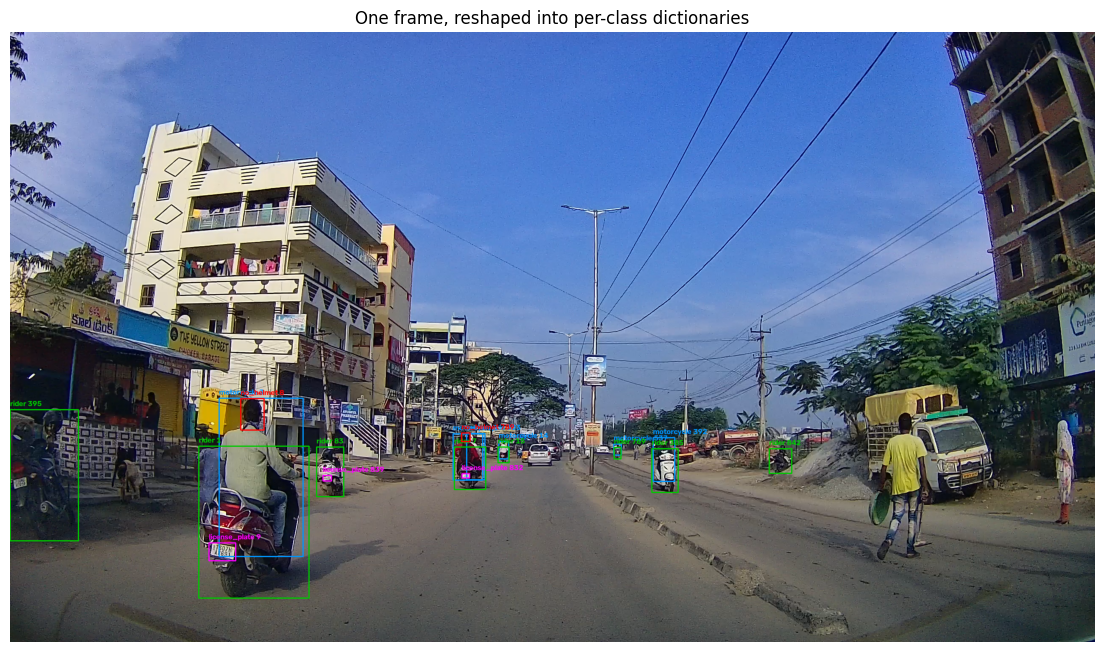

In [6]:
import cv2
import matplotlib.pyplot as plt

colors = {
    "motorcycle":    (255, 150, 0),
    "rider":         (0, 200, 0),
    "helmet":        (0, 255, 255),
    "no_helmet":     (0, 0, 255),
    "license_plate": (255, 0, 255),
}

img = frame.orig_img.copy()

for name, objects in det.items():
    for tid, box in objects.items():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), colors[name], 2)
        cv2.putText(img, f"{name} {tid}", (x1, max(y1 - 8, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors[name], 2)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("One frame, reshaped into per-class dictionaries")
plt.axis("off")
plt.show()

## **What's still missing**

Look at the frame above. The model has found riders, and it has found helmets,
but nothing yet says which helmet belongs to which rider. Same for riders
and motorcycles.

Detection produces objects. It doesn't produce relationships. Every box sits
on the frame independently, with no notion that this rider is on that
motorcycle. Building those links is the next stage and it turns out to be harder than detection, because the model can't help. The relationships have to be inferred
from geometry alone.